<a href="https://colab.research.google.com/github/Fawwzrf/Sentimen-Analysis/blob/main/Analisis_Sentimen_Mahasiswa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/brarajit18/student-feedback-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: fawwazrafi
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/brarajit18/student-feedback-dataset


100%|██████████| 34.4k/34.4k [00:00<00:00, 92.5MB/s]

# Laporan Proyek Analisis Sentimen Mahasiswa

### Identitas
**Nama/NIM:** NIM H1D023097  
**Institusi:** Informatika Universitas Jenderal Soedirman (Unsoed)

---

### Dokumentasi Proyek (README)

#### 1. Metodologi
Proyek ini mengikuti alur kerja pemrosesan data dan pembelajaran mesin sebagai berikut:
*   **Pengambilan Data:** Mengunduh dataset *Student Feedback* dari Kaggle menggunakan API `opendatasets`.
*   **Eksplorasi & Preprocessing:** Memuat data dari file Excel, melakukan restrukturisasi data (pivot/melt) agar kolom teks dan kategori selaras, serta membersihkan teks dari karakter khusus.
*   **Analisis Sentimen:** Mengklasifikasikan umpan balik menjadi POSITIVE atau NEGATIVE menggunakan model Transformer.
*   **Klasifikasi Zero-Shot:** Memetakan keluhan mahasiswa ke dalam sub-kategori audit spesifik (seperti Punctuality, Material Quality, dll.) tanpa pelatihan ulang model.
*   **Visualisasi:** Menggunakan Seaborn dan Matplotlib untuk menyajikan distribusi sentimen dan pemetaan masalah dalam bentuk heatmap.

#### 2. Dataset
*   **Sumber:** [Student Feedback Dataset (Kaggle)](https://www.kaggle.com/datasets/brarajit18/student-feedback-dataset).
*   **Struktur:** Dataset berisi feedback tekstual mengenai pengajaran (*teaching*), konten kursus (*course content*), pemeriksaan (*examination*), kerja lab (*lab work*), fasilitas perpustakaan (*library*), dan kegiatan ekstrakurikuler.

#### 3. Alasan Teknis Pemilihan Model
Model **DistilBERT** (khususnya `distilbert-base-uncased-finetuned-sst-2-english`) dipilih karena:
*   **Efisiensi Sumber Daya:** DistilBERT 40% lebih kecil dan 60% lebih cepat daripada model BERT standar, namun tetap mempertahankan sekitar 97% kinerjanya.
*   **Kesesuaian Perangkat:** Sangat cocok dijalankan pada environment terbatas tanpa memerlukan waktu inferensi yang lama.
*   **Akurasi:** Memberikan keseimbangan yang optimal antara kecepatan pemrosesan teks dan akurasi klasifikasi sentimen.

## Pipeline dan Cleaning Data



In [16]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import pipeline

DATA_PATH = '/content/student-feedback-dataset/finalDataset0.2.xlsx'
CATEGORIES_MAP = {
    'teaching.1': 'Teaching',
    'coursecontent.1': 'Course Content',
    'Examination': 'Examination',
    'labwork.1': 'Lab Work',
    ' library_facilities': 'Library',
    'extracurricular.1': 'Extracurricular'
}

# Cleaning Text
def clean_text(text):
    if pd.isna(text):
        return ""
    # Mengubah ke huruf kecil
    text = str(text).lower()
    # Menghapus karakter non-alfabet
    text = re.sub(r'[^a-z\s]', '', text)
    # Menghapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Load dan Preprocessing
def load_and_preprocess_data(path):
    # Memuat file Excel
    df_raw = pd.read_excel(path)

    processed_list = []
    for col, label in CATEGORIES_MAP.items():
        if col in df_raw.columns:
            temp_df = df_raw[[col]].rename(columns={col: 'text'})
            temp_df['category'] = label
            processed_list.append(temp_df)

    # Merge semua kategori
    df_combined = pd.concat(processed_list, ignore_index=True)
    df_combined['cleaned_text'] = df_combined['text'].apply(clean_text)

    # Menghapus baris kosong dan duplikat
    df_combined = df_combined[df_combined['cleaned_text'] != '']
    df_combined = df_combined.drop_duplicates().reset_index(drop=True)

    return df_combined

final_df = load_and_preprocess_data(DATA_PATH)

# Ringkasan
print("Dataset Information:")
print(final_df.info())
print("\nFirst 5 rows:")
print(final_df.head())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   text          740 non-null    object
 1   category      740 non-null    object
 2   cleaned_text  740 non-null    object
dtypes: object(3)
memory usage: 17.5+ KB
None

First 5 rows:
                                                text  category  \
0  teacher are punctual but they should also give...  Teaching   
1                                              Good   Teaching   
2  Excellent lectures are delivered by teachers a...  Teaching   
3                                               Good  Teaching   
4  teachers give us all the information required ...  Teaching   

                                        cleaned_text  
0  teacher are punctual but they should also give...  
1                                               good  
2  excellent lectures are delivered by tea

## Sentimen Analisis dan Klasifikasi Audit


In [17]:
from transformers import pipeline

# Sentiment Analysis Pipeline
sentiment_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

def get_sentiment(text):
    result = sentiment_pipeline(text)[0]
    return result['label'], result['score']

final_df[['sentiment', 'sentiment_score']] = final_df['cleaned_text'].apply(lambda x: pd.Series(get_sentiment(x)))

# Zero-Shot Classification Pipeline
zero_shot_pipeline = pipeline("zero-shot-classification", model="typeform/distilbert-base-uncased-mnli")
audit_labels = ["Punctuality", "Material Quality", "System Access", "Infrastructure", "Time Management"]

def get_audit_category(text):
    result = zero_shot_pipeline(text, candidate_labels=audit_labels)
    return result['labels'][0]

final_df['audit_sub_category'] = final_df['cleaned_text'].apply(get_audit_category)

# Hasil
print("Updated final_df with NLP Analysis:")
print(final_df.head())

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Updated final_df with NLP Analysis:
                                                text  category  \
0  teacher are punctual but they should also give...  Teaching   
1                                              Good   Teaching   
2  Excellent lectures are delivered by teachers a...  Teaching   
3                                               Good  Teaching   
4  teachers give us all the information required ...  Teaching   

                                        cleaned_text sentiment  \
0  teacher are punctual but they should also give...  NEGATIVE   
1                                               good  POSITIVE   
2  excellent lectures are delivered by teachers a...  POSITIVE   
3                                               good  POSITIVE   
4  teachers give us all the information required ...  NEGATIVE   

   sentiment_score audit_sub_category  
0         0.870117        Punctuality  
1         0.999816   Material Quality  
2         0.999353        Punctuality  
3         

## Visualisasi dan Hasil



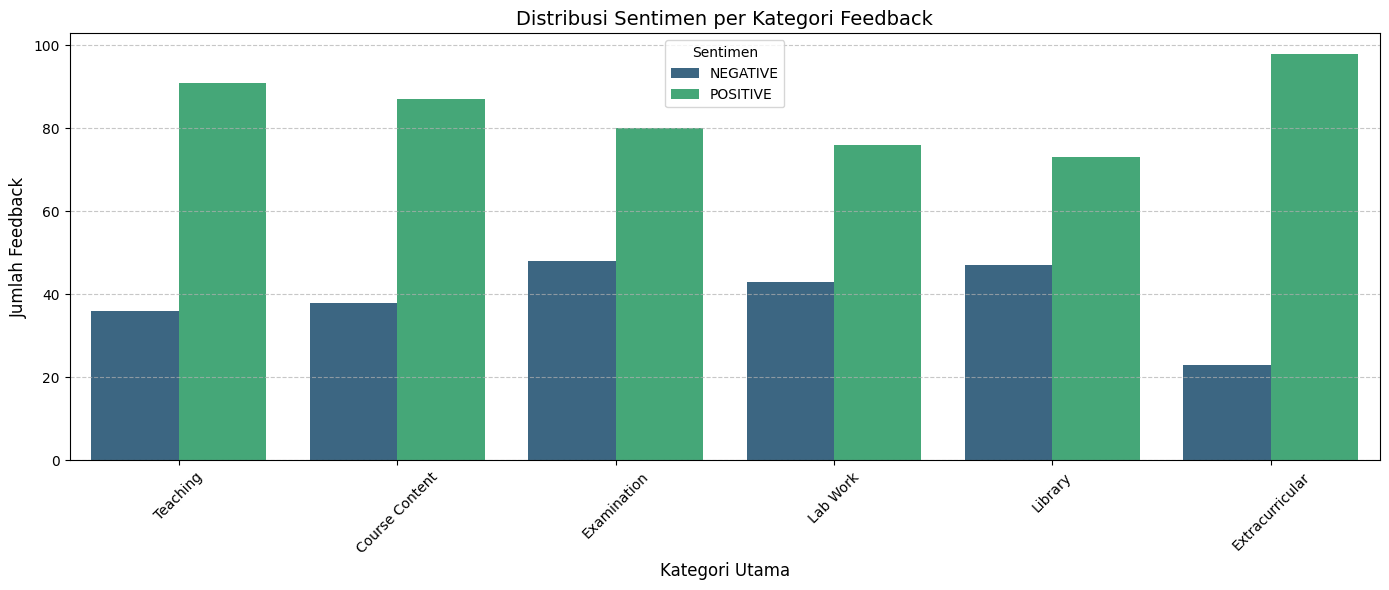

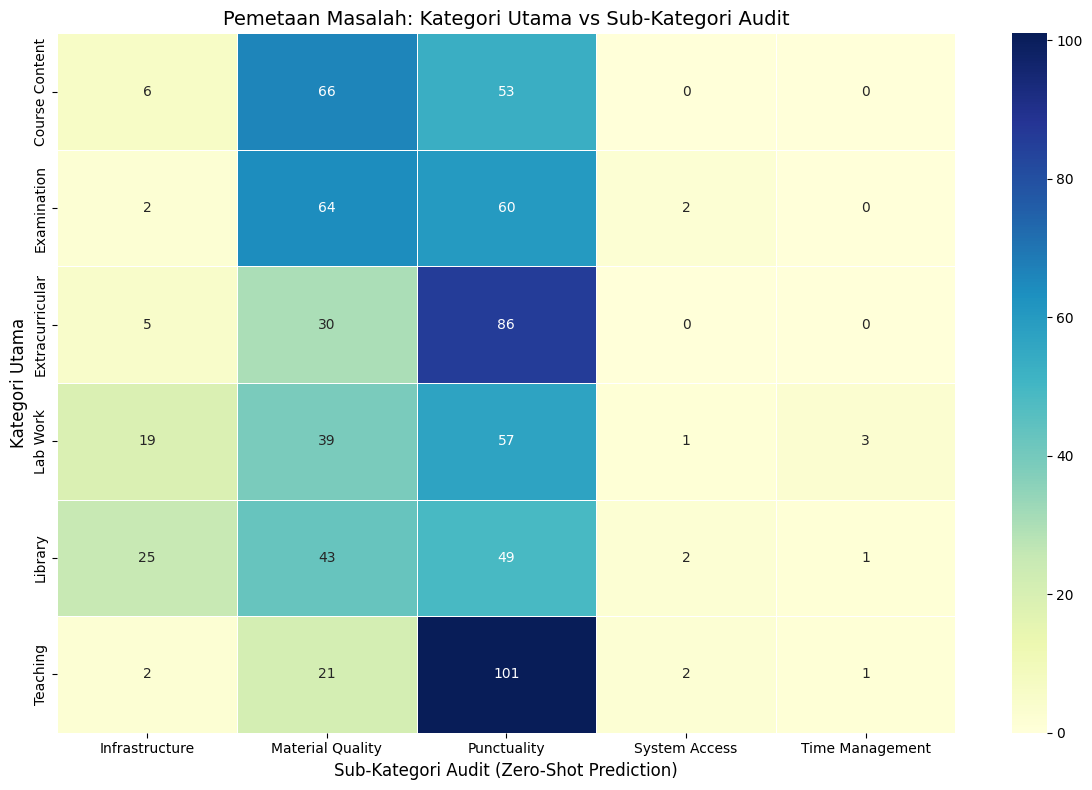

Pipeline Selesai. Data berhasil diekspor ke: student_feedback_analysis_results.csv


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Countplot per Category
plt.figure(figsize=(14, 6))
sns.countplot(data=final_df, x='category', hue='sentiment', palette='viridis')
plt.title('Distribusi Sentimen per Kategori Feedback', fontsize=14)
plt.xlabel('Kategori Utama', fontsize=12)
plt.ylabel('Jumlah Feedback', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Sentimen')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Heatmap Audit Sub-Category vs Main Category

pivot_audit = final_df.groupby(['category', 'audit_sub_category']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_audit, annot=True, cmap="YlGnBu", fmt='d', linewidths=.5)
plt.title('Pemetaan Masalah: Kategori Utama vs Sub-Kategori Audit', fontsize=14)
plt.ylabel('Kategori Utama', fontsize=12)
plt.xlabel('Sub-Kategori Audit (Zero-Shot Prediction)', fontsize=12)
plt.tight_layout()
plt.show()

# Export Hasil ke CSV
output_filename = 'student_feedback_analysis_results.csv'
final_df.to_csv(output_filename, index=False)
print(f"Pipeline Selesai. Data berhasil diekspor ke: {output_filename}")